In [11]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from data_loader import load_train_data, load_test_data
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
# 训练集：2022-01~2023-02
X_trains, X_tests, y_trains, y_tests = [], [], [], []
for month in [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2024) for m in range(1, 13)]:
    if month >= "2023-03":
        break
    malicious_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/malware_features_{month}.txt"
    benign_output_txt_path = f"/Data2/hxq/MalGuard/fea_ex/benign_features_{month}.txt"
    X_train, X_test, y_train, y_test = load_train_data(malicious_output_txt_path, benign_output_txt_path)
    X_trains.append(X_train)
    X_tests.append(X_test)
    y_trains.append(y_train)
    y_tests.append(y_test)
X_train = np.vstack(X_trains)
y_train = np.hstack(y_trains)
X_test = np.vstack(X_tests)
y_test = np.hstack(y_tests)

In [12]:
from train_with_lime import train_with_progress_bar, load_sensitive_apis

sensitive_api_file = r"/Data2/hxq/MalGuard/API-call-graph/gpt_prompt_result_closeness.json"
with open(sensitive_api_file, "r") as f:
    sensitive_apis = json.load(f)
sensitive_apis = load_sensitive_apis(sensitive_api_file) 

model_save_path = r"./models"
os.makedirs(model_save_path, exist_ok=True)

# NB
nb_model = GaussianNB()
train_with_progress_bar(nb_model, X_train, y_train, X_test, y_test, "Naive Bayes", model_save_path,
                        sensitive_apis, n_iter=100)

# MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1, warm_start=True, random_state=42)
train_with_progress_bar(mlp_model, X_train, y_train, X_test, y_test, "Multi Layer Perceptron",
                        model_save_path, sensitive_apis, n_iter=500)

# RF
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_with_progress_bar(rf_model, X_train, y_train, X_test, y_test, "Random Forest", model_save_path,
                        sensitive_apis, n_iter=100)

# DT
dt_model = DecisionTreeClassifier(random_state=42)
train_with_progress_bar(dt_model, X_train, y_train, X_test, y_test, "Decision Tree", model_save_path,
                        sensitive_apis, n_iter=100)

Training Naive Bayes:   0%|          | 0/100 [00:00<?, ?iter/s]

Training Naive Bayes: 100%|██████████| 100/100 [00:01<00:00, 86.46iter/s]



Naive Bayes Results
              precision    recall  f1-score   support

         0.0    0.54789   0.98862   0.70505      1406
         1.0    0.95031   0.21060   0.34479      1453

    accuracy                        0.59321      2859
   macro avg    0.74910   0.59961   0.52492      2859
weighted avg    0.75241   0.59321   0.52196      2859

Naive Bayes saved to ./models/naive_bayes/naive_bayes_model.pkl


Training Multi Layer Perceptron: 100%|██████████| 500/500 [00:41<00:00, 12.05iter/s]



Multi Layer Perceptron Results
              precision    recall  f1-score   support

         0.0    0.95604   0.99004   0.97275      1406
         1.0    0.99002   0.95595   0.97269      1453

    accuracy                        0.97272      2859
   macro avg    0.97303   0.97300   0.97272      2859
weighted avg    0.97331   0.97272   0.97272      2859

Multi Layer Perceptron saved to ./models/multi_layer_perceptron/multi_layer_perceptron_model.pkl


Training Random Forest: 100%|██████████| 100/100 [01:29<00:00,  1.12iter/s]



Random Forest Results
              precision    recall  f1-score   support

         0.0    0.95604   0.99004   0.97275      1406
         1.0    0.99002   0.95595   0.97269      1453

    accuracy                        0.97272      2859
   macro avg    0.97303   0.97300   0.97272      2859
weighted avg    0.97331   0.97272   0.97272      2859

Random Forest saved to ./models/random_forest/random_forest_model.pkl


Training Decision Tree: 100%|██████████| 100/100 [00:08<00:00, 11.94iter/s]


Decision Tree Results
              precision    recall  f1-score   support

         0.0    0.95649   0.98506   0.97057      1406
         1.0    0.98512   0.95664   0.97067      1453

    accuracy                        0.97062      2859
   macro avg    0.97080   0.97085   0.97062      2859
weighted avg    0.97104   0.97062   0.97062      2859

Decision Tree saved to ./models/decision_tree/decision_tree_model.pkl


In [13]:
def test_model(model, X_test, y_test, model_name):
    """
    测试模型并打印 precision, recall, f1
    """
    print(f"\n{'='*50}")
    print(f"Testing {model_name}")
    print(f"{'='*50}")

    # 预测
    y_pred = model.predict(X_test)

    # 计算指标
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # 打印结果
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    # 详细分类报告
    print(f"\n{classification_report(y_test, y_pred, target_names=['Benign', 'Malicious'])}")

    return precision, recall, f1

In [14]:
# 从 models 目录加载已训练的模型并测试
models_dir = r'/Data2/hxq/MalGuard/model_training/models'

results = []

# 可加载的模型列表
model_files = [
    "naive_bayes",
    "decision_tree",
    "random_forest",
    "multi_layer_perceptron",
]

# 测试模型在2022-01~2024-12每个月的数据集上的表现
# 先加载所有模型为全局变量
print("Loading all models...")
models = {}
for model_file in model_files:
    model_path = os.path.join(models_dir, model_file, f"{model_file}_model.pkl")
    if os.path.exists(model_path):
        models[model_file] = joblib.load(model_path)
        print(f"  Loaded: {model_file}")


Loading all models...
  Loaded: naive_bayes
  Loaded: decision_tree
  Loaded: random_forest
  Loaded: multi_layer_perceptron


In [15]:
# 定义月份列表
months = [f"{year}-{str(m).zfill(2)}" for year in range(2022, 2025) for m in range(1, 13)]

# 存储结果的DataFrame
results = []

# 先循环模型，再循环月份
for model_file, model in models.items():
    model_name = model_file.replace("_", " ").title()
    print(f"\n{'#'*20} Testing {model_name} {'#'*20}")
    
    for month in months:
        # if month < '2023-03':
        #     continue  # 跳过2023-03之前的月份
        mal_data_path = f"/Data2/hxq/MalGuard/fea_ex/malware_features_{month}.txt"
        ben_data_path = f"/Data2/hxq/MalGuard/fea_ex/benign_features_{month}.txt"

        X_test, y_test = load_test_data(mal_data_path, ben_data_path)
        
        # 预测并计算指标
        y_pred = model.predict(X_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            "Model": model_name,
            "Month": month,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        })
        
        print(f"  {month}: P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}")

# 转换为DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Results Summary:")
print("="*60)
print(results_df.to_string(index=False))

# 保存结果
results_df.to_csv("/Data2/hxq/MalGuard/model_training/monthly_results.csv", index=False)
print("\nResults saved to monthly_results.csv")


#################### Testing Naive Bayes ####################
  2022-01: P=0.8663, R=0.8175, F1=0.8112
  2022-02: P=0.7791, R=0.6042, F1=0.5306
  2022-03: P=0.8773, R=0.8478, F1=0.8448
  2022-04: P=0.9651, R=0.9643, F1=0.9643
  2022-05: P=0.9286, R=0.9167, F1=0.9161
  2022-06: P=0.8077, R=0.6875, F1=0.6537
  2022-07: P=0.8667, R=0.8367, F1=0.8333
  2022-08: P=0.7143, R=0.5450, F1=0.4330
  2022-09: P=0.7818, R=0.6129, F1=0.5447
  2022-10: P=0.7556, R=0.6118, F1=0.5483
  2022-11: P=0.8459, R=0.7898, F1=0.7809
  2022-12: P=0.7645, R=0.6770, F1=0.6479
  2023-01: P=0.8318, R=0.7466, F1=0.7292
  2023-02: P=0.7431, R=0.5755, F1=0.4872
  2023-03: P=0.7050, R=0.5538, F1=0.4538
  2023-04: P=0.8240, R=0.7741, F1=0.7650
  2023-05: P=0.8302, R=0.7429, F1=0.7247
  2023-06: P=0.8382, R=0.7609, F1=0.7464
  2023-07: P=0.7905, R=0.6395, F1=0.5857
  2023-08: P=0.7357, R=0.6212, F1=0.5689
  2023-09: P=0.7750, R=0.5909, F1=0.5087
  2023-10: P=0.7941, R=0.6500, F1=0.6011
  2023-11: P=0.7214, R=0.5946, F1=0

/home/hxq/.conda/envs/malguard/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hxq/.conda/envs/malguard/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  2023-01: P=0.8578, R=0.8014, F1=0.7932
  2023-02: P=0.9944, R=0.9944, F1=0.9944
  2023-03: P=0.8566, R=0.8205, F1=0.8159
  2023-04: P=0.8967, R=0.8852, F1=0.8843
  2023-05: P=0.8646, R=0.8143, F1=0.8077
  2023-06: P=0.8286, R=0.7391, F1=0.7201
  2023-07: P=0.8116, R=0.7442, F1=0.7296
  2023-08: P=0.7357, R=0.6212, F1=0.5689
  2023-09: P=0.7412, R=0.6136, F1=0.5548
  2023-10: P=0.8659, R=0.8167, F1=0.8103
  2023-11: P=0.7681, R=0.7297, F1=0.7197
  2023-12: P=0.9647, R=0.9620, F1=0.9620
  2024-01: P=0.7667, R=0.5625, F1=0.4589
  2024-02: P=0.7418, R=0.6058, F1=0.5413
  2024-03: P=0.9642, R=0.9641, F1=0.9641
  2024-04: P=0.9188, R=0.9103, F1=0.9099
  2024-05: P=0.8228, R=0.7500, F1=0.7351
  2024-06: P=0.9325, R=0.9283, F1=0.9281
  2024-07: P=0.7893, R=0.7222, F1=0.7051
  2024-08: P=0.7427, R=0.5929, F1=0.5186
  2024-09: P=0.7751, R=0.5867, F1=0.5053
  2024-10: P=0.8145, R=0.7051, F1=0.6770
  2024-11: P=0.2407, R=0.4643, F1=0.3171
  2024-12: P=0.7857, R=0.6250, F1=0.5636

###############

/home/hxq/.conda/envs/malguard/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  2022-10: P=0.8465, R=0.7961, F1=0.7883
  2022-11: P=0.9313, R=0.9204, F1=0.9198
  2022-12: P=0.9185, R=0.9027, F1=0.9017
  2023-01: P=0.8510, R=0.7877, F1=0.7776
  2023-02: P=0.9946, R=0.9946, F1=0.9946
  2023-03: P=0.8572, R=0.8154, F1=0.8099
  2023-04: P=0.8108, R=0.7296, F1=0.7107
  2023-05: P=0.8535, R=0.7929, F1=0.7836
  2023-06: P=0.7805, R=0.6087, F1=0.5379
  2023-07: P=0.8054, R=0.7326, F1=0.7156
  2023-08: P=0.7705, R=0.5758, F1=0.4826
  2023-09: P=0.7612, R=0.6477, F1=0.6048
  2023-10: P=0.8191, R=0.7167, F1=0.6919
  2023-11: P=0.7392, R=0.6622, F1=0.6326
  2023-12: P=0.7814, R=0.6076, F1=0.5393
  2024-01: P=0.7857, R=0.6250, F1=0.5636
  2024-02: P=0.7786, R=0.6731, F1=0.6389
  2024-03: P=0.9704, R=0.9698, F1=0.9698
  2024-04: P=0.9022, R=0.8821, F1=0.8807
  2024-05: P=0.7985, R=0.6625, F1=0.6191
  2024-06: P=0.9352, R=0.9305, F1=0.9303
  2024-07: P=0.8293, R=0.7407, F1=0.7221
  2024-08: P=0.7427, R=0.5929, F1=0.5186
  2024-09: P=0.7638, R=0.5467, F1=0.4345
  2024-10: P=0.8

/home/hxq/.conda/envs/malguard/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


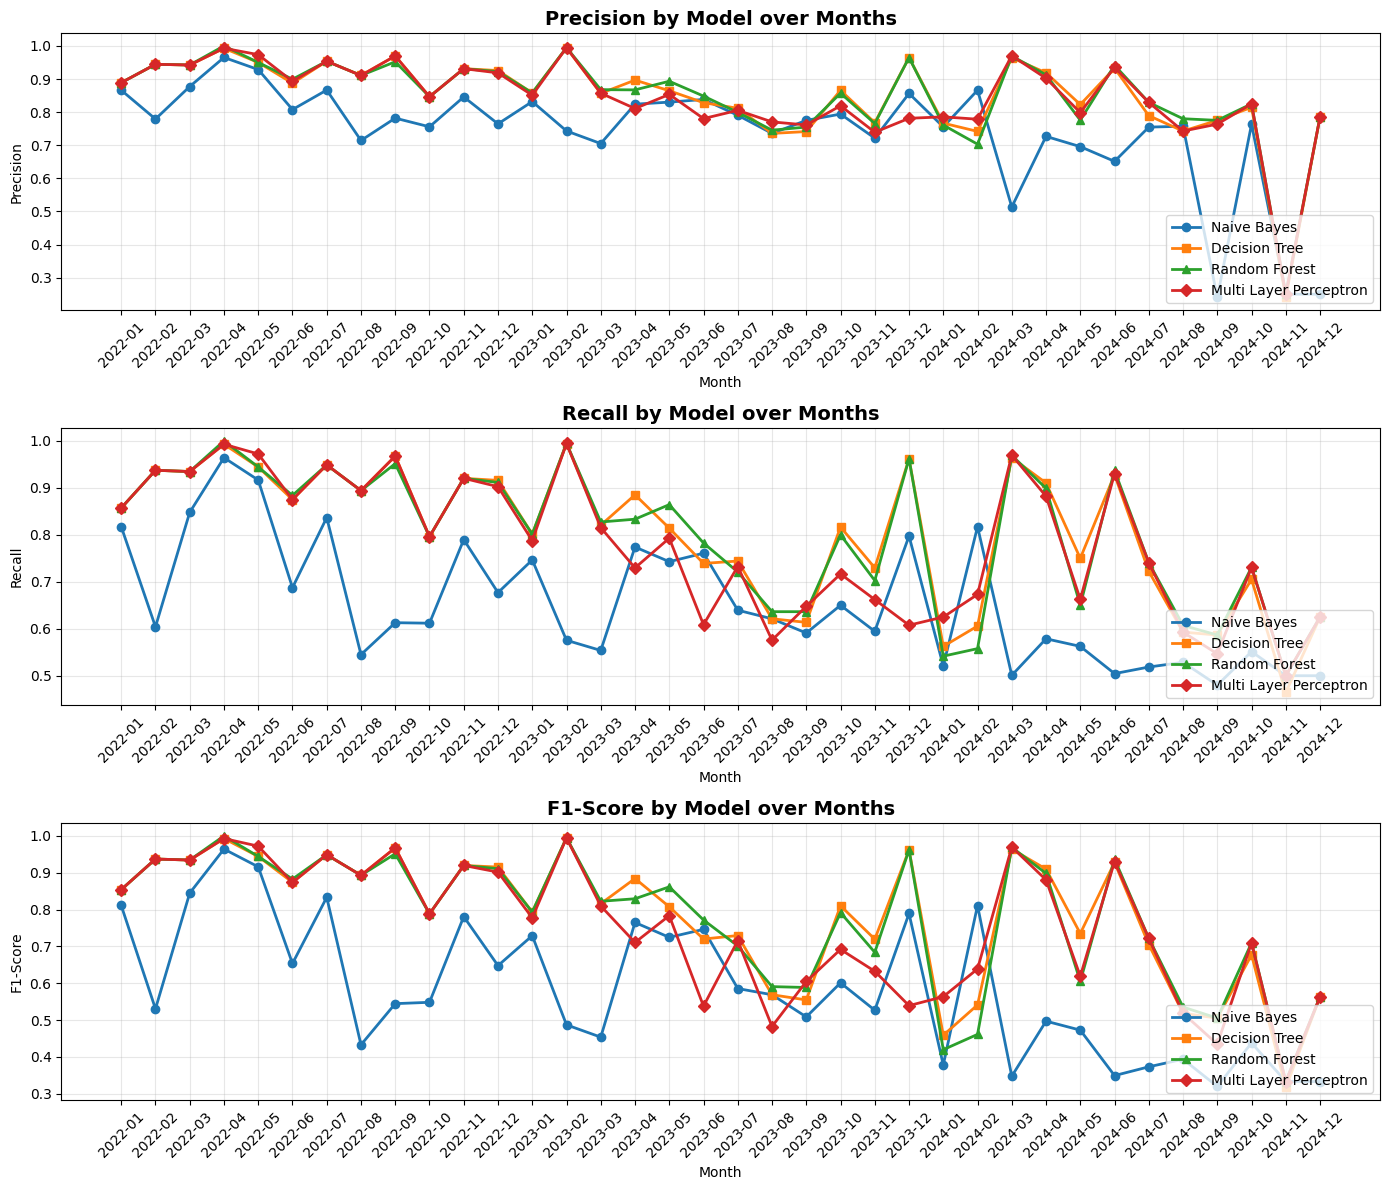


Chart saved to monthly_metrics_comparison.png


In [16]:
# 绘制不同模型在不同月份的指标折线图
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 获取所有模型名称
model_names = results_df['Model'].unique()
months = results_df['Month'].unique()

# 创建3个子图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

# 图1: Precision
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[0].plot(model_data['Month'], model_data['Precision'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[0].set_title('Precision by Model over Months', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Precision')
axes[0].legend(loc='lower right')
axes[0].set_xticks(range(0, len(months)))
axes[0].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[0].grid(True, alpha=0.3)
# axes[0].set_ylim(0.8, 1.0)

# 图2: Recall
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[1].plot(model_data['Month'], model_data['Recall'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[1].set_title('Recall by Model over Months', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Recall')
axes[1].legend(loc='lower right')
axes[1].set_xticks(range(0, len(months)))
axes[1].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[1].grid(True, alpha=0.3)
# axes[1].set_ylim(0.8, 1.0)

# 图3: F1-Score
for idx, model_name in enumerate(model_names):
    model_data = results_df[results_df['Model'] == model_name]
    axes[2].plot(model_data['Month'], model_data['F1'], 
                 marker=markers[idx], color=colors[idx], 
                 linewidth=2, markersize=6, label=model_name)
axes[2].set_title('F1-Score by Model over Months', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('F1-Score')
axes[2].legend(loc='lower right')
axes[2].set_xticks(range(0, len(months)))
axes[2].set_xticklabels([months[i] for i in range(0, len(months))], rotation=45)
axes[2].grid(True, alpha=0.3)
# axes[2].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.savefig('/Data2/hxq/MalGuard/model_training/monthly_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to monthly_metrics_comparison.png")

In [ ]:
# 分析几个性能下降明显的点，random forest模型，2023-09，2024-01，2024-02，2024-09
